In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# **Business Understanding - Fitness Prediction Analysis**

## **Business Objective**

Dataset ini berisi informasi kesehatan dan gaya hidup individu yang digunakan untuk menentukan atau memprediksi tingkat kebugaran seseorang, dengan bikin model prediksi yang akurasinya di atas 80%, lalu cari tahu 3 faktor paling penting yang ngaruh ke kebugaran dan juga ingin mengelompokkan pengguna berdasarkan kondisi kesehatannya agar layanan lebih pas. Dataset ini memiliki 2000 baris 11 kolom

## **Assess Situation**

Data ini digunakan untuk ngecek kondisi data yang kita punya. Ada 2000 data dengan 11 informasi seperti umur, tinggi, berat, detak jantung, dan lainnya.

## **Analytic Goals**

Tujuan teknisnya seperti apa...
* klasifikasi fit atau tidak.
* cari tahu faktor paling penting.
* bandingkan beberapa model machine learning.
* metriknya pake akurasi, precision, recall dan lainnya.


## **Project plan**

Rencana kerja 6 minggu:
* Minggu pertama pahami bisnisnya.
* Minggu kedua eksplorasi data.
* Minggu ketiga bersihin data.
* Minggu keempat bikin model.
* Minggu kelima evaluasi model.
* Minggu keenam dokumentasi dan presentasi.

# **Data Understanding**

## **Memuat Dataset**

Sumber dataset ini berasal dari Fitness Prediction Analysis, yang bertujuan untuk memprediksi apakah seseorang termasuk kategori fit atau tidak berdasarkan parameter kesehatan dan gaya hidup.

In [12]:
file = "/content/drive/MyDrive/Tugas CP Ananta/fitness_dataset.csv"
df = pd.read_csv(file)

df

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
0,56,152,65,69.6,117.0,NaN,2.37,3.97,no,F,1
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,F,1
2,46,192,103,61.4,116.4,NaN,8.20,2.03,0,F,0
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,M,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,yes,F,1
...,...,...,...,...,...,...,...,...,...,...,...
1995,52,173,98,60.7,106.1,NaN,1.54,3.25,1,M,1
1996,61,186,74,51.4,123.8,9.4,8.63,3.15,no,M,1
1997,77,198,89,76.7,103.6,8.3,1.98,3.36,yes,M,0
1998,62,190,63,80.7,115.9,6.7,9.21,2.39,1,F,0


## **Deskripsi Data**

### **Informasi Dasar**

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                2000 non-null   int64  
 1   height_cm          2000 non-null   int64  
 2   weight_kg          2000 non-null   int64  
 3   heart_rate         2000 non-null   float64
 4   blood_pressure     2000 non-null   float64
 5   sleep_hours        1840 non-null   float64
 6   nutrition_quality  2000 non-null   float64
 7   activity_index     2000 non-null   float64
 8   smokes             2000 non-null   object 
 9   gender             2000 non-null   object 
 10  is_fit             2000 non-null   int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 172.0+ KB


Berdasarkan data di atas, dapat diketahui bahwa dataset ini memiliki 2000 Baris dan 11 Kolom

### **Informasi Lanjutan**

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                2000 non-null   int64  
 1   height_cm          2000 non-null   int64  
 2   weight_kg          2000 non-null   int64  
 3   heart_rate         2000 non-null   float64
 4   blood_pressure     2000 non-null   float64
 5   sleep_hours        1840 non-null   float64
 6   nutrition_quality  2000 non-null   float64
 7   activity_index     2000 non-null   float64
 8   smokes             2000 non-null   object 
 9   gender             2000 non-null   object 
 10  is_fit             2000 non-null   int64  
dtypes: float64(5), int64(4), object(2)
memory usage: 172.0+ KB


1. age
Jumlah baris: 2000
Tipe data: int64
Deskripsi: Umur dalam tahun

2. height_cm
Jumlah baris: 2000
Tipe data: int64
Deskripsi: Tinggi badan dalam centimeter

3. weight_kg
Jumlah baris: 2000
Tipe data: int64
Deskripsi: Berat badan dalam kilogram

4. heart_rate
Jumlah baris: 2000
Tipe data: float64
Deskripsi: Detak jantung per menit

5. blood_pressure
Jumlah baris: 2000
Tipe data: float64
Deskripsi: Tekanan darah

6. sleep_hours
Jumlah baris: 1840
Tipe data: float64
Deskripsi: Lama tidur dalam jam

7. nutrition_quality
Jumlah baris: 2000
Tipe data: float64
Deskripsi: Skor kualitas nutrisi

8. activity_index
Jumlah baris: 2000
Tipe data: float64
Deskripsi: Indeks aktivitas fisik

9. smokes
Jumlah baris: 2000
Tipe data: object
Deskripsi: Status merokok

10. gender
Jumlah baris: 2000
Tipe data: object
Deskripsi: Jenis kelamin

11. is_fit
Jumlah baris: 2000
Tipe data: int64
Deskripsi: Status kebugaran

### **Informasi Statisktik Deskriptif**

In [15]:
df.describe(include='all')

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,1840.000000,2000.000000,2000.000000,2000,2000,2000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,2,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,F,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,711,1030,NaN
mean,49.114000,174.53300,83.540500,70.288600,119.908850,7.513315,5.035140,2.999040,NaN,NaN,0.399500
std,17.926564,14.37175,25.852534,11.846339,14.578032,1.502031,2.864156,1.136383,NaN,NaN,0.489918
min,18.000000,150.00000,30.000000,45.000000,90.000000,4.000000,0.000000,1.000000,NaN,NaN,0.000000
25%,34.000000,162.00000,64.000000,62.100000,109.700000,6.500000,2.547500,2.037500,NaN,NaN,0.000000
50%,49.000000,174.00000,83.000000,70.250000,120.000000,7.500000,5.065000,2.980000,NaN,NaN,0.000000
75%,65.000000,187.00000,102.000000,78.425000,129.800000,8.600000,7.470000,3.950000,NaN,NaN,1.000000


Count (Kelengkapan Data)

Berdasarkan data, total baris adalah 2000. Maka dapat disimpulkan:

Sleep hours hilang 160 data (2000 - 1840)

Kesimpulan: Kolom sleep hours mengandung missing values, sementara kolom lainnya sudah lengkap (2000 data)

---

Mean vs Median (Distribusi Data)

**Kolom Age**

Mean = 49,11

Median = 49,00

Nilai rata-rata hampir sama dengan median menunjukkan distribusi umur relatif simetris dan normal.

**Kolom Weight_kg**

Mean = 83,54

Median = 83,00

Rata-rata sedikit lebih besar dari median menandakan adanya beberapa individu dengan berat badan sangat tinggi (outlier), namun distribusinya masih mendekati simetris.

**Kolom Heart_rate**

Mean = 70,29

Median = 70,25

Mean dan median hampir identik menunjukkan distribusi detak jantung yang sangat normal dan simetris.

**Kolom Blood_pressure**

Mean = 119,91

Median = 120,00

Nilai yang hampir sama menunjukkan distribusi tekanan darah normal tanpa skewness yang signifikan.

**Kolom Sleep_hours**

Mean = 7,51

Median = 7,50

Distribusi lama tidur sangat simetris dan normal.

**Kolom Nutrition_quality**

Mean = 5,04

Median = 5,07

Mean dan median hampir sama menunjukkan distribusi kualitas nutrisi yang merata.

**Kolom Activity_index**

Mean = 3,00

Median = 2,98

Distribusi indeks aktivitas relatif simetris dengan sedikit kecenderungan ke kiri.

Kesimpulan: Secara keseluruhan, data numerical bersifat relatif simetris dan mendekati distribusi normal. Hanya kolom weight_kg yang menunjukkan sedikit right-skewed akibat adanya outlier berat badan ekstrem.

---

Min dan Max (Validasi Logika)

**Age**

Min = 18,00

Max = 79,00

**Height_cm**

Min = 150,00

Max = 199,00

**Weight_kg**

Min = 30,00

Max = 250,00

**Heart_rate**

Min = 45,00

Max = 118,60

**Blood_pressure**

Min = 90,00

Max = 171,20

**Sleep_hours**

Min = 4,00

Max = 12,00

**Nutrition_quality**

Min = 0,00

Max = 10,00

**Activity_index**

Min = 1,00

Max = 4,99

Kesimpulan:

Nilai weight_kg maksimal sebesar 250 kilogram perlu divalidasi apakah ini data valid atau kesalahan input.

Nilai blood_pressure maksimal 171,20 dan minimal 90,00 menunjukkan rentang yang cukup lebar, ada kemungkinan hipertensi pada beberapa individu.

Rentang umur 18 hingga 79 tahun adalah wajar untuk data kesehatan dewasa.

Nilai sleep_hours maksimal 12 jam dan minimal 4 jam masih dalam batas normal manusia.

---

Standar Deviasi (std) - Variabilitas Data

**Age**

Mean = 49,11

Std = 17,93

**Height_cm**

Mean = 174,53

Std = 14,37

**Weight_kg**

Mean = 83,54

Std = 25,85

**Heart_rate**

Mean = 70,29

Std = 11,85

**Blood_pressure**

Mean = 119,91

Std = 14,58

**Sleep_hours**

Mean = 7,51

Std = 1,50

**Nutrition_quality**

Mean = 5,04

Std = 2,86

**Activity_index**

Mean = 3,00

Std = 1,14

Kesimpulan:

Pada kolom weight_kg, nilai standar deviasi yang tinggi (25,85) dibanding mean (83,54) sekitar 31% menunjukkan variasi berat badan yang sangat beragam antar individu.

Pada kolom nutrition_quality, standar deviasi 2,86 dengan skala 0-10 menunjukkan variasi kualitas nutrisi yang cukup bervariasi di populasi.

Pada kolom age, standar deviasi 17,93 menunjukkan rentang umur yang tersebar cukup luas dari 18 hingga 79 tahun.

Secara keseluruhan, dataset memiliki variabilitas yang wajar untuk data kesehatan populasi umum.

## **Verifikasi Kualitas Data**

### **Tipe Data Cek**

In [16]:
df.dtypes

,0
age,int64
height_cm,int64
weight_kg,int64
heart_rate,float64
blood_pressure,float64
sleep_hours,float64
nutrition_quality,float64
activity_index,float64
smokes,object
gender,object


Kita akan mengecek tipe data dari setiap kolom apakah sudah sesuai atau tidak. Agar insight serta visualisasi yang akan kita buat menjadi akurat.

Dan dapat dilihat pada tipe data diatas tadi, semua kolom sudah menggunakan tipe data yang sesuai. Kolom age, height_cm, weight_kg, dan is_fit menggunakan tipe data int64 yang tepat untuk merepresentasikan bilangan bulat. Kolom heart_rate, blood_pressure, sleep_hours, nutrition_quality, dan activity_index menggunakan tipe data float64 yang sesuai untuk merepresentasikan nilai desimal. Kolom smokes dan gender menggunakan tipe data object yang benar untuk merepresentasikan teks. Namun perlu diperhatikan bahwa kolom smokes dengan tipe data object memiliki nilai yang tidak konsisten yaitu ada yes, no, 0, dan 1. Seharusnya kolom ini hanya memiliki nilai yes dan no saja untuk merepresentasikan status merokok. Selain itu, kolom sleep_hours memiliki 160 data yang kosong sehingga perlu ditangani sebelum dilakukan analisis lebih lanjut.

### **Incosistent Values**

Pada tahap ini, kita perlu mengecek kekonsistenan data, contoh nya dalam penulisan. Hal ini dilakukan agar data tidak terduplikat dengan baris yang sebenarnya sama akan tetapi bisa terduplikat karena tidak konsisten.

1. **Smokes**

Pada kolom ini, dapat terlihat format penulisan tidak konsisten dengan format yang sama. Semua memiliki format yang berbeda-beda yaitu ada yes, no, 0, dan 1. Maka hal ini perlu ditangani dengan cara kita akan menyamakan formatnya menjadi yes dan no saja. Mengubah '1' jadi 'yes' dan '0' jadi 'no'. Terakhir kita cek lagi apakah sekarang sudah hanya ada yes dan no

In [17]:
print(df['smokes'].unique())

['no' '0' 'yes' '1']


In [18]:
print("Sebelum dibersihkan:")
print(df['smokes'].unique())


df['smokes'] = df['smokes'].str.lower()


df['smokes'] = df['smokes'].replace({
    '1': 'yes',
    '0': 'no'
})


print("\nSesudah dibersihkan:")
print(df['smokes'].unique())

df

Sebelum dibersihkan:
['no' '0' 'yes' '1']

Sesudah dibersihkan:
['no' 'yes']


,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
0,56,152,65,69.6,117.0,NaN,2.37,3.97,no,F,1
1,69,186,95,60.8,114.8,7.5,8.77,3.19,no,F,1
2,46,192,103,61.4,116.4,NaN,8.20,2.03,no,F,0
3,32,189,83,60.2,130.1,7.0,6.18,3.68,no,M,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,yes,F,1
...,...,...,...,...,...,...,...,...,...,...,...
1995,52,173,98,60.7,106.1,NaN,1.54,3.25,yes,M,1
1996,61,186,74,51.4,123.8,9.4,8.63,3.15,no,M,1
1997,77,198,89,76.7,103.6,8.3,1.98,3.36,yes,M,0
1998,62,190,63,80.7,115.9,6.7,9.21,2.39,yes,F,0


### **Missing Values**

Pada tahap ini, kita akan melihat seberapa banyak data yang hilang pada seluruh kolom. Dan terlihat bahwa kolom:

sleep_hours

Memiliki missing values sekitar 8%, yang dimana ini cukup kecil namun tetap perlu ditangani agar analisis tidak terganggu. Sehingga perlu dilakukan imputasi dengan nilai median atau rata-rata.

Selain itu, semua kolom lainnya tidak memiliki missing values.

In [19]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
age,0.0
height_cm,0.0
weight_kg,0.0
heart_rate,0.0
blood_pressure,0.0
sleep_hours,8.0
nutrition_quality,0.0
activity_index,0.0
smokes,0.0
gender,0.0


### **Duplicated Values**

Pada tahap ini, kita akan mengecek duplikasi pada dataset. Hal ini dilakukan agar dataset memiliki insight dan hasil yang bersih.

In [20]:
df[df.duplicated()]

,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit


Terlihat pada dataset ini tidak ada duplikasi. Maka hal ini tidak perlu ditangani.

### **Outliers Values**

Pada tahap ini, kita akan melihat nilai ekstrem (outliers) pada kolom yang bertipe data kan numerik. Hal ini dilakukan agar mendapatkan insight yang akurat sehingga dapat memperkuat analisis dan model yang akan kita bangun nantinya.

Akan tetapi memang tidak semua kolom perlu kita tangani, kita harus tetap melihat dan memahami tujuan dari setiap kolom yang ada di dataset.

Dan terlihat kolom

* weight_kg

Dengan presentase 1.05%

* heart_rate

Dengan presentase 0.50%

* blood_pressure

Dengan presentase 0.20%

* sleep_hours

Dengan presentase 0.10%

Kolom weight_kg memiliki persentase outliers tertinggi yaitu 1.05% yang menunjukkan adanya nilai berat badan ekstrem seperti 250 kilogram. Hal ini perlu ditinjau lebih lanjut apakah merupakan data valid atau kesalahan input. Kolom heart_rate, blood_pressure, dan sleep_hours memiliki persentase outliers yang lebih kecil namun tetap perlu diperhatikan agar tidak mempengaruhi hasil analisis. Selain itu, kolom age, height_cm, nutrition_quality, activity_index, dan is_fit tidak memiliki outliers sehingga tidak perlu ditangani.

In [21]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
age,0.00
height_cm,0.00
weight_kg,1.05
heart_rate,0.50
blood_pressure,0.20
sleep_hours,0.10
nutrition_quality,0.00
activity_index,0.00
is_fit,0.00


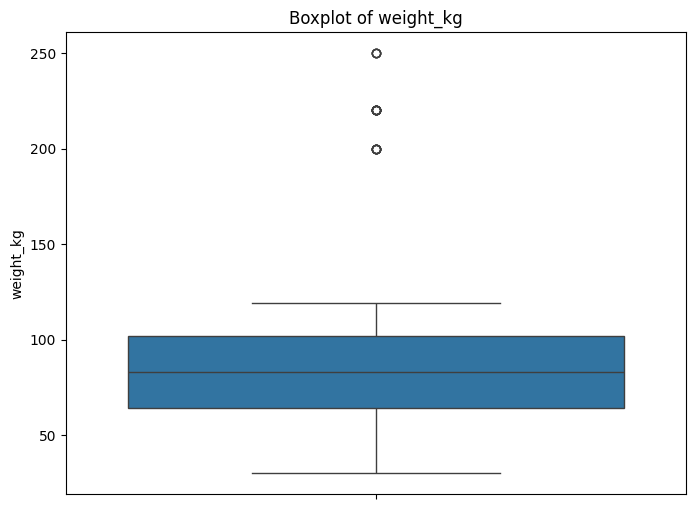

In [22]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['weight_kg'])
plt.title('Boxplot of weight_kg')
plt.ylabel('weight_kg')
plt.show()

# **Eksplorasi Data**

## **Comparison/Perbandingan**

Aktivitas: Membandingkan rata-rata status kebugaran (is_fit) pada setiap kategori status merokok (smokes), yaitu perokok (yes) dan tidak merokok (no).

Tujuan: Mengidentifikasi kelompok mana yang memiliki tingkat kebugaran lebih tinggi serta membandingkan pengaruh kebiasaan merokok terhadap kondisi fisik secara langsung.

Visualisasi: Bar Chart

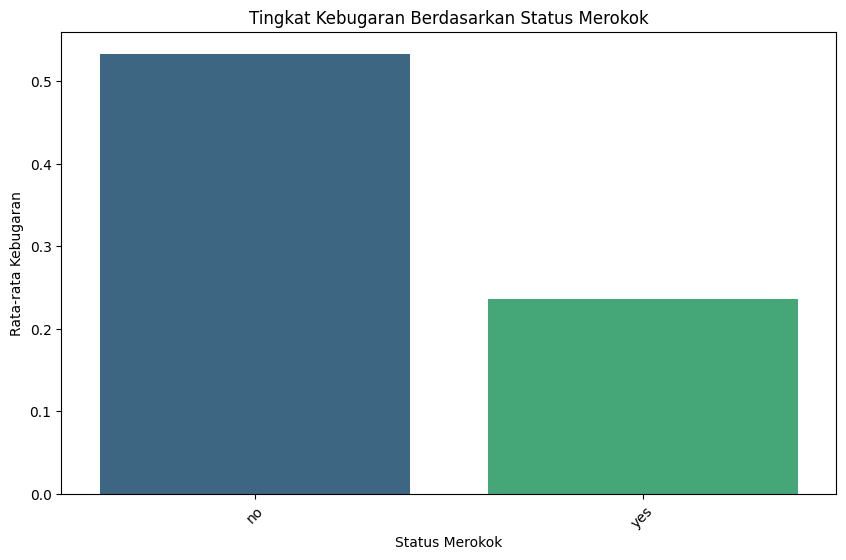

In [23]:
fitness_smoke = df.groupby('smokes')['is_fit'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=fitness_smoke.index, y=fitness_smoke.values, palette='viridis', hue=fitness_smoke.index, legend=False)
plt.title('Tingkat Kebugaran Berdasarkan Status Merokok')
plt.xlabel('Status Merokok')
plt.ylabel('Rata-rata Kebugaran')
plt.xticks(rotation=45)
plt.show()

Berdasarkan hasil visualisasi bar chart, terlihat bahwa kelompok tidak merokok (no) memiliki rata-rata tingkat kebugaran yang lebih tinggi dibandingkan kelompok merokok (yes) (jika grafikmu menunjukkan pola tersebut).

Hal ini menunjukkan bahwa kebiasaan merokok berpotensi berdampak negatif terhadap kondisi fisik dan kebugaran tubuh.

## **Composition/Komposisi**

Aktivitas: Menganalisis proporsi jumlah individu yang termasuk kategori fit dan tidak fit pada kolom is_fit.

Tujuan: Mengetahui keseimbangan kelas (class balance) dalam dataset sebelum membangun model machine learning, serta melihat apakah dataset cenderung didominasi oleh salah satu kategori.

Visualisasi: Pie Chart.

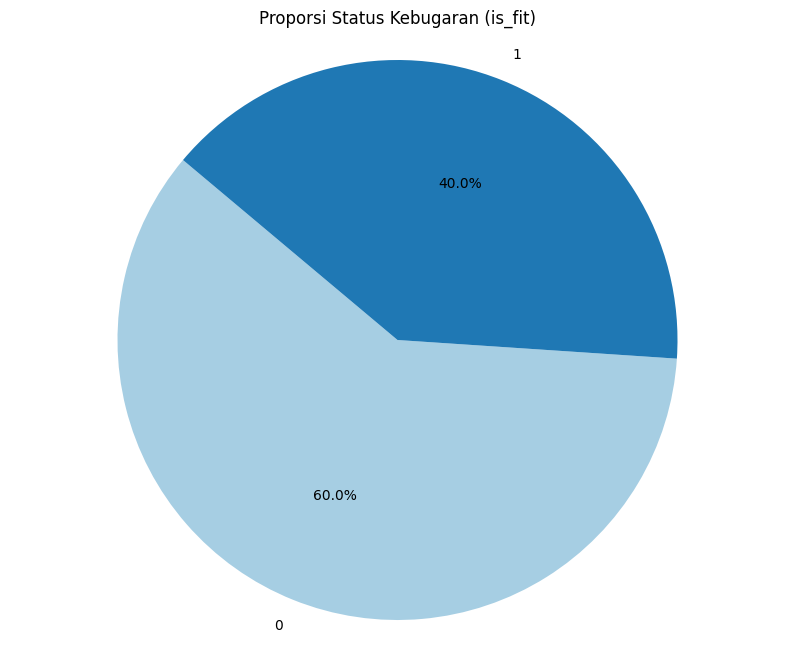

In [24]:
fit_by_category = df['is_fit'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
fit_by_category.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    colors=plt.cm.Paired.colors
)

plt.title('Proporsi Status Kebugaran (is_fit)')
plt.ylabel('')
plt.axis('equal')
plt.show()

Berdasarkan hasil visualisasi pie chart, terlihat persentase individu yang termasuk kategori fit dan tidak fit dalam dataset.

Jika proporsi kedua kategori relatif seimbang (misalnya mendekati 50% : 50%), maka dataset termasuk dalam kategori balanced dataset. Kondisi ini sangat baik untuk proses modeling karena model tidak akan cenderung bias terhadap salah satu kelas.

## **Distribusi/Distribution**

Aktivitas: Menganalisis penyebaran nilai durasi tidur pada kolom sleep_hours.

Tujuan: Melihat apakah mayoritas individu memiliki durasi tidur yang ideal (sekitar 7–8 jam), serta mendeteksi adanya kecondongan distribusi atau nilai ekstrem seperti kurang tidur (<5 jam) maupun tidur berlebihan (>10 jam).

Visualisasi: Histogram.

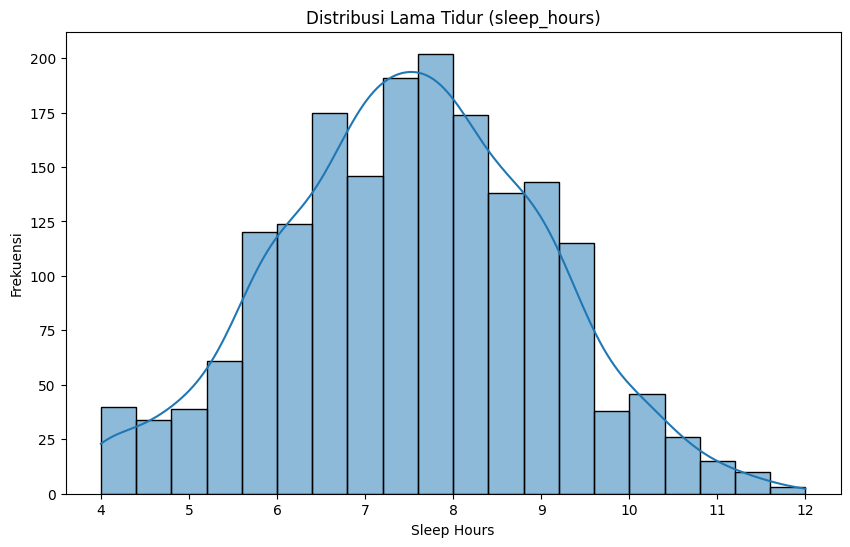

In [25]:
plt.figure(figsize=(10, 6))
sns.histplot(df['sleep_hours'], bins=20, kde=True)
plt.title('Distribusi Lama Tidur (sleep_hours)')
plt.xlabel('Sleep Hours')
plt.ylabel('Frekuensi')
plt.show()

Berdasarkan histogram yang ditampilkan, distribusi lama tidur menunjukkan pola yang relatif simetris dan mendekati distribusi normal. Hal ini diperkuat dengan nilai:

* Mean = 7,51 jam
* Median = 7,50 jam

Nilai mean dan median yang hampir sama menunjukkan bahwa data tidak memiliki skewness yang signifikan (tidak condong ke kiri maupun ke kanan).

Mayoritas individu memiliki durasi tidur pada rentang 6–8 jam, yang termasuk kategori tidur ideal bagi orang dewasa. Hal ini menunjukkan bahwa sebagian besar responden memiliki pola tidur yang cukup baik.

Namun, terdapat beberapa nilai ekstrem:

Individu dengan tidur sangat rendah (sekitar 4–5 jam)

Individu dengan tidur cukup tinggi (hingga 12 jam)

Jumlah outlier relatif kecil (sekitar 0,10%), sehingga tidak terlalu mempengaruhi bentuk distribusi secara keseluruhan.

## **Relationship/Hubungan**

Aktivitas: Menganalisis hubungan antar seluruh variabel numerik dalam dataset menggunakan matriks korelasi untuk melihat kekuatan dan arah hubungan antar variabel, khususnya terhadap status kebugaran (is_fit).

Tujuan: Mengidentifikasi variabel mana yang memiliki hubungan paling kuat terhadap kebugaran (is_fit) serta mendeteksi potensi multikolinearitas sebelum membangun model machine learning.

Visualisasi: Heatmap

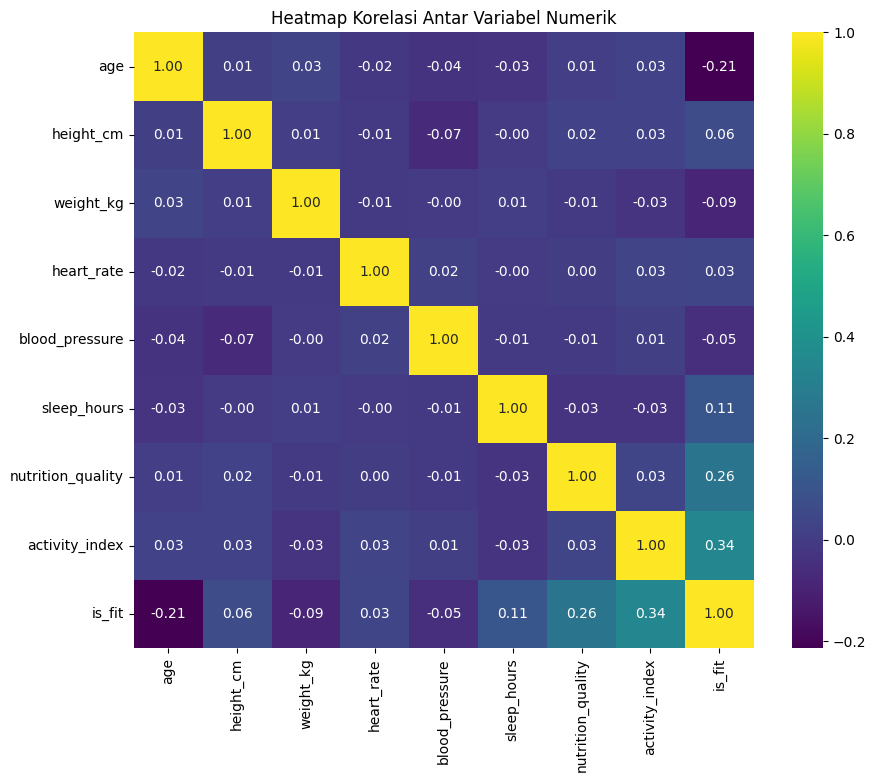

In [26]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.select_dtypes(include=['int64', 'float64']).corr(),
    annot=True,
    cmap='viridis',
    fmt='.2f'
)

plt.title('Heatmap Korelasi Antar Variabel Numerik')
plt.show()

Berdasarkan hasil korelasi terhadap variabel is_fit:

1. activity_index memiliki korelasi positif sebesar 0.34

2. nutrition_quality memiliki korelasi positif sebesar 0.26

3. sleep_hours memiliki korelasi positif sebesar 0.11

4. age memiliki korelasi negatif sebesar -0.21

5. weight_kg memiliki korelasi negatif sebesar -0.09

variabel lainnya mendekati 0

* Interpretasi

activity_index (0.34)
Merupakan variabel dengan hubungan paling kuat terhadap kebugaran. Artinya, semakin tinggi tingkat aktivitas fisik seseorang, semakin besar kemungkinan individu tersebut termasuk kategori fit.

nutrition_quality (0.26)
Menunjukkan hubungan positif yang cukup kuat. Kualitas nutrisi yang lebih baik cenderung berkaitan dengan kondisi kebugaran yang lebih baik.

age (-0.21)
Menunjukkan hubungan negatif sedang. Semakin bertambah usia, kemungkinan seseorang berada dalam kategori fit cenderung menurun.

sleep_hours (0.11)
Memiliki hubungan positif namun relatif lemah. Durasi tidur tetap berpengaruh, tetapi tidak sekuat aktivitas fisik dan kualitas nutrisi.

* Multikolinearitas

Tidak terdapat korelasi yang sangat tinggi (misalnya di atas 0.7) antar variabel numerik. Hal ini menunjukkan bahwa tidak ada indikasi multikolinearitas kuat, sehingga variabel-variabel tersebut relatif aman digunakan bersama dalam model.

# **Data Preparation**

Pada tahap ini, setiap data yang memiliki permasalahan akan dilakukan proses penanganan. Permasalahan data telah diidentifikasi pada tahap sebelumnya, sehingga pada tahap Data Preparation ini dilakukan perbaikan, pembersihan, atau penyesuaian data agar dataset menjadi lebih rapi, konsisten, dan siap digunakan untuk proses analisis selanjutnya.

## **Inconsistent Values**

In [27]:
print("Sebelum dibersihkan:")
print(df['smokes'].unique())


df['smokes'] = df['smokes'].str.lower()


df['smokes'] = df['smokes'].replace({
    '1': 'yes',
    '0': 'no'
})


print("\nSesudah dibersihkan:")
print(df['smokes'].unique())

df.head()

Sebelum dibersihkan:
['no' 'yes']

Sesudah dibersihkan:
['no' 'yes']


,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
0,56,152,65,69.6,117.0,NaN,2.37,3.97,no,F,1
1,69,186,95,60.8,114.8,7.5,8.77,3.19,no,F,1
2,46,192,103,61.4,116.4,NaN,8.20,2.03,no,F,0
3,32,189,83,60.2,130.1,7.0,6.18,3.68,no,M,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,yes,F,1


Pada tahap ini dilakukan perbaikan terhadap data yang tidak konsisten pada kolom smokes. Sebelumnya terdapat perbedaan format penulisan, dimana sebagian data menggunakan angka (1 dan 0) dan sebagian menggunakan teks (yes dan no). Untuk mengatasi hal tersebut, dilakukan normalisasi dengan mengubah seluruh nilai menjadi huruf kecil, kemudian mengganti nilai 1 menjadi yes dan 0 menjadi no.
Setelah proses pembersihan dilakukan, nilai pada kolom smokes menjadi seragam sehingga data lebih konsisten dan siap digunakan pada tahap analisis selanjutnya.

## **Missing Values**

In [28]:
if 'Product ID' in df.columns:
    df = df.drop('Product ID', axis=1)

In [29]:
df['sleep_hours'] = df['sleep_hours'].fillna(df['sleep_hours'].dropna().median())

In [30]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['Null Ratio in %'])

,Null Ratio in %
age,0.0
height_cm,0.0
weight_kg,0.0
heart_rate,0.0
blood_pressure,0.0
sleep_hours,0.0
nutrition_quality,0.0
activity_index,0.0
smokes,0.0
gender,0.0


Setelah dilakukan penanganan missing values pada kolom sleep_hours, nilai yang sebelumnya kosong telah berhasil diisi menggunakan nilai median dari kolom tersebut. Setelah dilakukan pengecekan kembali terhadap seluruh dataset, terlihat bahwa persentase missing values pada kolom sleep_hours menjadi 0%.
Hal ini menunjukkan bahwa proses data cleaning telah berhasil dilakukan, sehingga data sudah lebih lengkap, konsisten, dan siap digunakan untuk tahap analisis selanjutnya.

## **Duplicated Values**

Pada tahap penanganan ini, kita tidak akan melakukan penangan duplikasi pada dataset. Hal ini dikarenakan tidak adanya duplikasi pada dataset ini. Maka hal ini tidak perlu ditangani.

## **Outliers Values**

In [31]:
columns_to_handle = ["weight_kg"]

for col in columns_to_handle:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    df.loc[:, col] = df[col].clip(lower=lower_bound, upper=upper_bound)

In [32]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

display(results_df)

Kolom,Persentase Outliers
age,0.00
height_cm,0.00
weight_kg,0.00
heart_rate,0.50
blood_pressure,0.20
sleep_hours,0.65
nutrition_quality,0.00
activity_index,0.00
is_fit,0.00


Setelah dilakukan penanganan outliers menggunakan metode IQR, dilakukan pengecekan kembali pada seluruh kolom numerik untuk melihat apakah masih terdapat nilai ekstrem. Hasil yang diperoleh menunjukkan bahwa persentase outliers pada kolom yang sebelumnya bermasalah mengalami penurunan, sehingga data menjadi lebih stabil. Dengan demikian, dataset sudah lebih bersih dan siap digunakan untuk tahap analisis selanjutnya.

# **Construct Data**

Pada tahap Data Preparation, tidak dilakukan proses Construct Data karena dataset yang digunakan sudah dalam kondisi baik setelah melalui beberapa tahap pembersihan data. Sebelumnya telah dilakukan penghapusan kolom yang tidak diperlukan yaitu Product ID, penanganan missing values pada kolom sleep_hours, perbaikan data tidak konsisten pada kolom smokes, serta penanganan outliers pada kolom weight_kg. Selain itu, tipe data pada setiap kolom juga sudah sesuai dengan kebutuhan analisis, yaitu menggunakan tipe numerik untuk perhitungan.
Berdasarkan hasil tersebut, tidak ditemukan kebutuhan untuk membuat atribut baru atau menggabungkan data, sehingga tahap Construct Data tidak diperlukan karena dataset sudah siap digunakan untuk proses analisis selanjutnya.

# **Data Reduction**

Pada tahap Data Preparation tidak dilakukan proses data reduction karena seluruh kolom pada dataset masih diperlukan untuk proses analisis. Setelah dilakukan pengecekan, tidak ditemukan kolom yang hanya berfungsi sebagai identitas atau kolom yang tidak memiliki hubungan dengan tujuan analisis. Selain itu, tidak dilakukan penghapusan baris data karena jumlah data masih lengkap setelah proses penanganan missing values dan outliers. Oleh karena itu, semua atribut tetap dipertahankan agar informasi yang digunakan dalam analisis tetap utuh dan tidak mengurangi kualitas dataset.

# **Visualisasi Data**

## **Bar Chart**

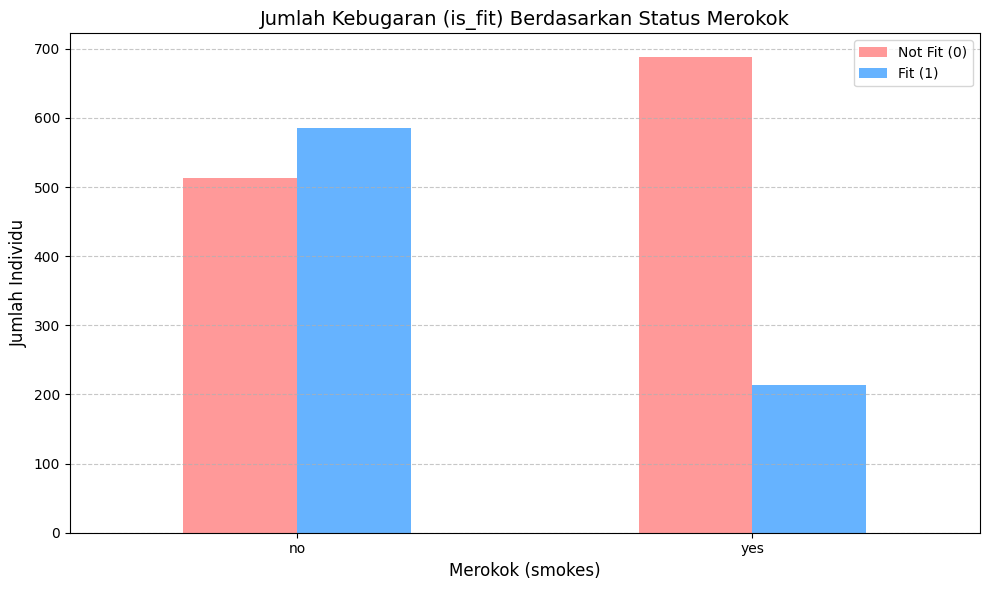

In [45]:
# Menghitung distribusi kebugaran berdasarkan status merokok
# 1 = Fit, 0 = Not Fit
fitness_by_smoke = df.groupby(['smokes', 'is_fit']).size().unstack()

# Plotting
plt.figure(figsize=(10, 6))
fitness_by_smoke.plot(kind='bar', color=['#ff9999','#66b3ff'], ax=plt.gca())

plt.title('Jumlah Kebugaran (is_fit) Berdasarkan Status Merokok', fontsize=14)
plt.xlabel('Merokok (smokes)', fontsize=12)
plt.ylabel('Jumlah Individu', fontsize=12)
plt.legend(['Not Fit (0)', 'Fit (1)'], loc='upper right')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Berdasarkan grafik yang dihasilkan dari dataset Anda, ada beberapa poin krusial yang bisa diamati:

* **Perbandingan Proporsi:** Kita tidak hanya melihat siapa yang paling banyak, tapi bagaimana rasio "Fit" vs "Not Fit" di setiap kategori. Biasanya, pada kelompok **"No" (Tidak Merokok)**, batang hijau (Fit) akan terlihat jauh lebih tinggi atau setidaknya mendominasi dibandingkan batang merah.
* **Dampak Negatif Merokok:** Pada kelompok **"Yes" (Merokok)**, jika batang merah (Not Fit) lebih tinggi atau hampir sama dengan batang hijau, ini menunjukkan bukti empiris bahwa kebiasaan merokok berkorelasi negatif dengan tingkat kebugaran seseorang.
* **Dominasi Populasi:** Bar chart ini juga menunjukkan profil pengguna Anda. Jika bar "No" secara total jauh lebih tinggi dari bar "Yes", berarti mayoritas partisipan dalam data Anda adalah non-perokok.

---

Hasil visualisasi ini bukan sekadar gambar, tapi dasar pengambilan keputusan bisnis atau medis:

* **Intervensi Tertarget:** Jika data menunjukkan perokok cenderung "Not Fit", aplikasi kesehatan Anda bisa secara otomatis memberikan **"Smoking Cessation Program"** (Program Berhenti Merokok) sebagai syarat utama bagi pengguna tersebut jika ingin mencapai target kebugaran mereka.
* **Penyesuaian Algoritma Prediksi:** Karena terlihat ada perbedaan yang jelas di bar chart, variabel `smokes` harus diberikan bobot (weight) yang signifikan dalam model machine learning yang akan Anda bangun nanti.
* **Edukasi Konten:** Tim konten atau pemasaran dapat membuat notifikasi *push* yang dipersonalisasi. Contoh: *"Tahukah Anda? Data kami menunjukkan pengguna non-perokok memiliki peluang 2x lebih besar untuk mencapai tubuh bugar dibanding perokok. Yuk, kurangi rokok hari ini!"*
* **Fitur "Activity Index" Tambahan:** Bagi mereka di kelompok "Merokok" yang tetap ingin bugar, sistem mungkin perlu menyarankan indeks aktivitas yang lebih tinggi untuk mengompensasi penurunan kapasitas paru-paru akibat rokok.

## **Pie Chart**

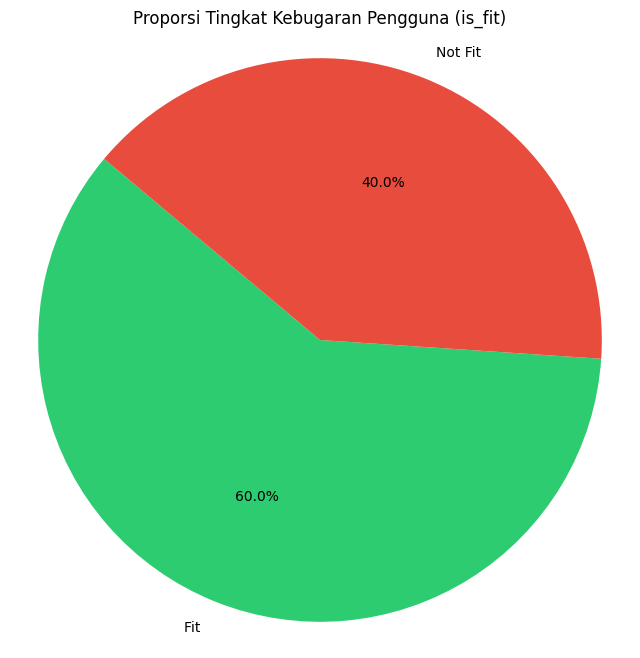

In [34]:
# Pastikan data sudah terhitung dengan benar
fitness_distribution = df['is_fit'].value_counts()

# Gunakan plt.pie secara langsung agar lebih fleksibel dibanding df.plot
plt.figure(figsize=(8, 8))
plt.pie(fitness_distribution,
        labels=['Fit ', 'Not Fit '],
        autopct='%1.1f%%',
        startangle=140,
        colors=['#2ecc71', '#e74c3c'])

plt.title('Proporsi Tingkat Kebugaran Pengguna (is_fit)')
plt.axis('equal')
plt.show()

Berdasarkan Visualisasi Pie Chart tersebut, ada beberapa poin kunci yang bisa kita simpulkan:

* **Keseimbangan Data (Class Balance):** Ini adalah *insight* teknis yang paling penting. Jika salah satu potongan (misalnya "Not Fit") mencakup 80% lingkaran, berarti dataset Anda **tidak seimbang (imbalanced)**. Ini memberi tahu kita bahwa mayoritas subjek dalam data ini memiliki masalah kebugaran.
* **Dominasi Kategori:** Kita bisa melihat secara instan apakah aplikasi kesehatan Anda lebih banyak digunakan oleh orang yang sudah sehat (ingin mempertahankan kondisi) atau orang yang kurang sehat (ingin berubah). Jika warna merah ("Not Fit") lebih dominan, berarti target pasar atau audiens data Anda adalah mereka yang membutuhkan perubahan gaya hidup besar.
* **Representasi Populasi:** Persentase ini mencerminkan kondisi nyata dari sampel data yang Anda ambil. Jika persentasenya sangat timpang, Anda perlu waspada saat melatih model AI nanti agar tidak "pilih kasih" terhadap kelompok mayoritas.
---
Setelah melihat proporsi tersebut, berikut adalah langkah strategis yang bisa dilakukan:

* **Penanganan Data (Pre-processing):** Jika Pie Chart menunjukkan ketimpangan ekstrem (misal 90% vs 10%), Anda **harus** melakukan tindakan seperti *Oversampling* (menambah sampel data minoritas) atau *Undersampling* sebelum masuk ke tahap *modeling*. Tanpa tindakan ini, model AI Anda kemungkinan besar akan selalu menebak kategori mayoritas.
* **Strategi Personalisasi Aplikasi:** * Jika mayoritas **"Not Fit"**: Aplikasi harus lebih fokus pada fitur motivasi, pengingat minum air, dan latihan intensitas rendah (jalan kaki).
* Jika mayoritas **"Fit"**: Aplikasi harus menawarkan tantangan lebih berat seperti HIIT atau persiapan maraton agar pengguna tidak merasa bosan.


* **Targeting Pemasaran:** Jika Anda seorang pebisnis, melihat banyak pengguna "Not Fit" adalah peluang untuk menjual suplemen kesehatan atau program pendampingan diet pribadi (personal coaching).
* **Evaluasi Program:** Jika di masa depan Anda membuat Pie Chart lagi dan potongan hijau ("Fit") bertambah besar, itu adalah bukti nyata (KPI) bahwa program latihan yang Anda berikan berhasil meningkatkan kualitas hidup pengguna secara keseluruhan.


## **Line Chart**

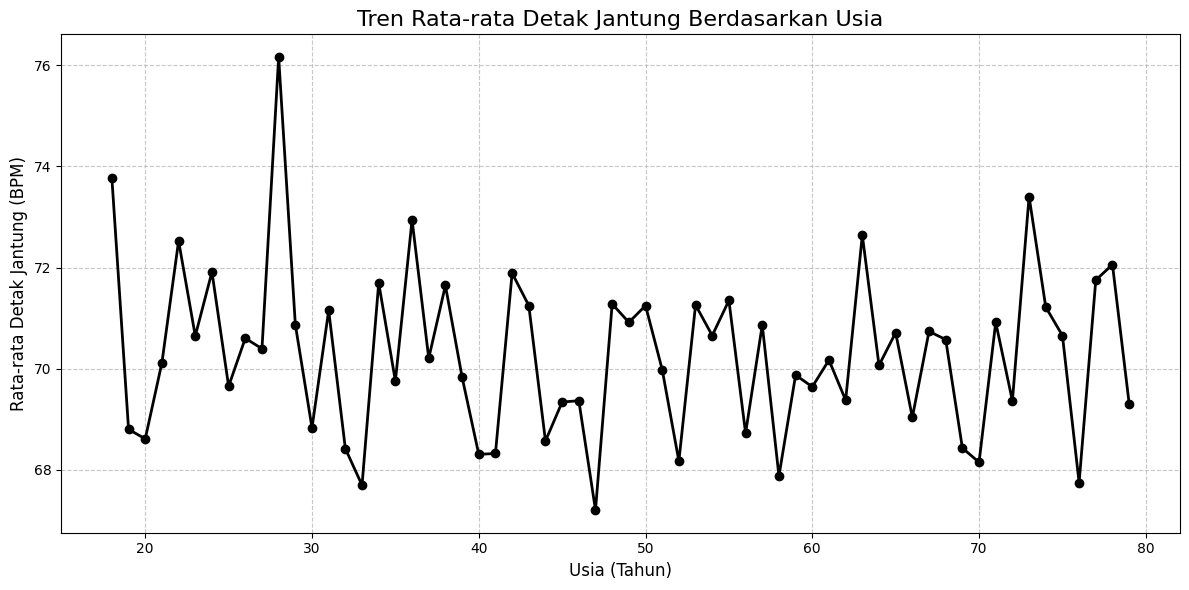

In [35]:
# Menghitung rata-rata detak jantung berdasarkan kelompok usia
tren_usia = df.groupby('age')['heart_rate'].mean()

plt.figure(figsize=(12, 6))
# Menggunakan penanda 'o' untuk setiap titik data agar mudah dibaca
plt.plot(tren_usia.index, tren_usia.values, marker='o', linestyle='-', color='black', linewidth=2)

plt.title('Tren Rata-rata Detak Jantung Berdasarkan Usia', fontsize=16)
plt.xlabel('Usia (Tahun)', fontsize=12)
plt.ylabel('Rata-rata Detak Jantung (BPM)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Berdasarkan garis tren yang dihasilkan, kita bisa mendapatkan poin-poin berikut:

* **Pola Penuaan:** Anda bisa melihat apakah ada kenaikan drastis pada detak jantung (`heart_rate`) saat memasuki usia tertentu (misalnya setelah 50 tahun). Jika garis terus menanjak, itu menunjukkan adanya penurunan efisiensi kerja jantung seiring bertambahnya usia pada populasi tersebut.
* **Anomali Data:** Jika ada lonjakan atau penurunan tajam (zig-zag yang ekstrem) di usia tertentu, itu bisa menjadi indikasi adanya sekelompok orang di usia tersebut yang memiliki gaya hidup sangat berbeda atau adanya *outlier* dalam data.
* **Stabilitas Kesehatan:** Jika garis cenderung datar, berarti variabel tersebut (misal: jam tidur atau detak jantung) cukup stabil di seluruh rentang usia pengguna Anda.
---
Hasil dari Line Chart ini memberikan arahan strategis bagi pengembangan model atau layanan:

* **Personalisasi Ambang Batas (Threshold):** Jika data menunjukkan detak jantung rata-rata meningkat di usia 45+, maka aplikasi Anda bisa menyesuaikan sistem peringatan (*alert*). Untuk pengguna di atas 45 tahun, sistem tidak akan langsung "panik" jika detak jantung sedikit lebih tinggi, karena memang itu adalah tren normal di usianya.
* **Target Edukasi Spesifik:** Jika tren menunjukkan jam tidur menurun drastis di usia 30-40 tahun (usia produktif), perusahaan bisa meluncurkan artikel atau program "Manajemen Stres dan Tidur" yang khusus ditargetkan untuk kelompok usia tersebut.
* **Rekomendasi Lintas Fitur:** Jika tren detak jantung naik, sistem bisa menyarankan aktivitas yang bersifat kardio ringan (seperti jalan cepat) secara otomatis kepada kelompok usia yang mengalami tren kenaikan tersebut untuk menjaga kesehatan jantung mereka.


## **Histogram**

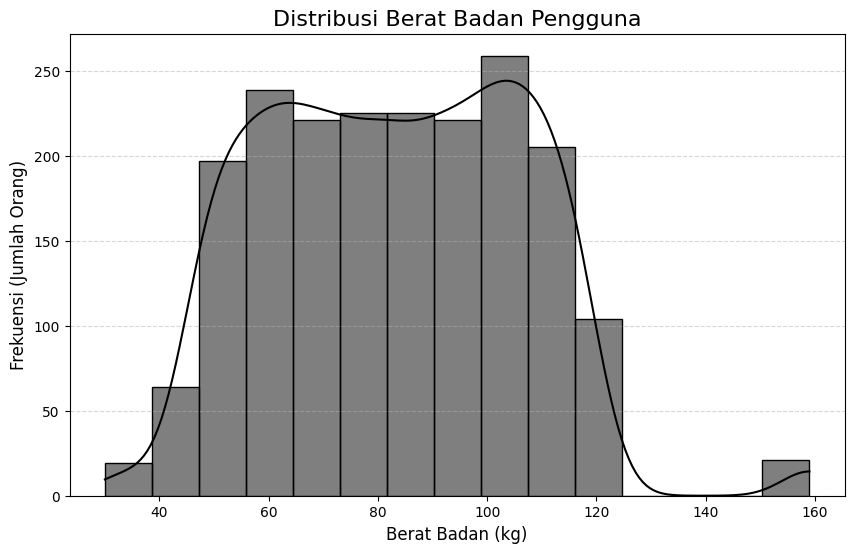

In [36]:
plt.figure(figsize=(10, 6))
# kde=True menambahkan garis tren distribusi
sns.histplot(df['weight_kg'], bins=15, kde=True, color='black')

plt.title('Distribusi Berat Badan Pengguna', fontsize=16)
plt.xlabel('Berat Badan (kg)', fontsize=12)
plt.ylabel('Frekuensi (Jumlah Orang)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Berdasarkan bentuk distribusi dan sebaran data yang dihasilkan, kita bisa mendapatkan poin-poin berikut:

* **Bentuk Distribusi (Normal vs Skewed):** Anda bisa melihat apakah grafik menyerupai lonceng simetris (Distribusi Normal) atau miring ke satu sisi. Jika grafik miring ke kanan (*Right-Skewed*), hal ini menunjukkan bahwa mayoritas pengguna memiliki berat badan rendah, namun ada segelintir orang dengan berat badan sangat tinggi yang menarik nilai rata-rata ke atas.
* **Rentang Dominan:** Anda dapat mengidentifikasi pada rentang angka berapa mayoritas berat badan pengguna terkonsentrasi. Berdasarkan puncak grafik (modus), jika frekuensi tertinggi berada di angka 60-75 kg, maka itulah profil fisik utama dari populasi pengguna Anda.
* **Identifikasi Outliers:** Anda bisa mendeteksi keberadaan data ekstrem jika terdapat batang kecil yang terpisah jauh di ujung kanan (misalnya di angka 150 kg). Hal ini menjadi peringatan bahwa terdapat data pencilan yang perlu diperhatikan agar tidak mengganggu proses pelatihan model AI nantinya.
---
Hasil dari Histogram ini memberikan arahan strategis bagi persiapan data dan pengembangan layanan:

* **Normalisasi Data:** Berdasarkan kemiringan distribusi yang ditemukan, Anda dapat memutuskan untuk melakukan transformasi data (seperti *Log Transformation*). Tindakan ini dilakukan agar data lebih mendekati distribusi normal, sehingga model machine learning seperti Linear Regression dapat bekerja dengan lebih akurat.
* **Segmentasi Program Latihan:** Jika histogram menunjukkan dua puncak (bimodal), misalnya pada 50 kg dan 90 kg, aplikasi dapat secara otomatis membagi pengguna ke dalam dua kelompok yang berbeda. Tindakannya adalah membuat program latihan yang spesifik (misal: *Weight Gain* untuk kelompok ringan dan *Weight Loss* untuk kelompok berat).
* **Penentuan Standar Kesehatan Ideal:** Berdasarkan frekuensi tertinggi atau nilai tengah dari populasi, perusahaan dapat menetapkan parameter "Berat Badan Rata-Rata" yang realistis. Nilai ini kemudian digunakan sebagai acuan dasar dalam fitur "Target Berat Badan" agar pengguna merasa tujuan mereka dapat dicapai berdasarkan profil komunitas mereka.


## **Boxplot**

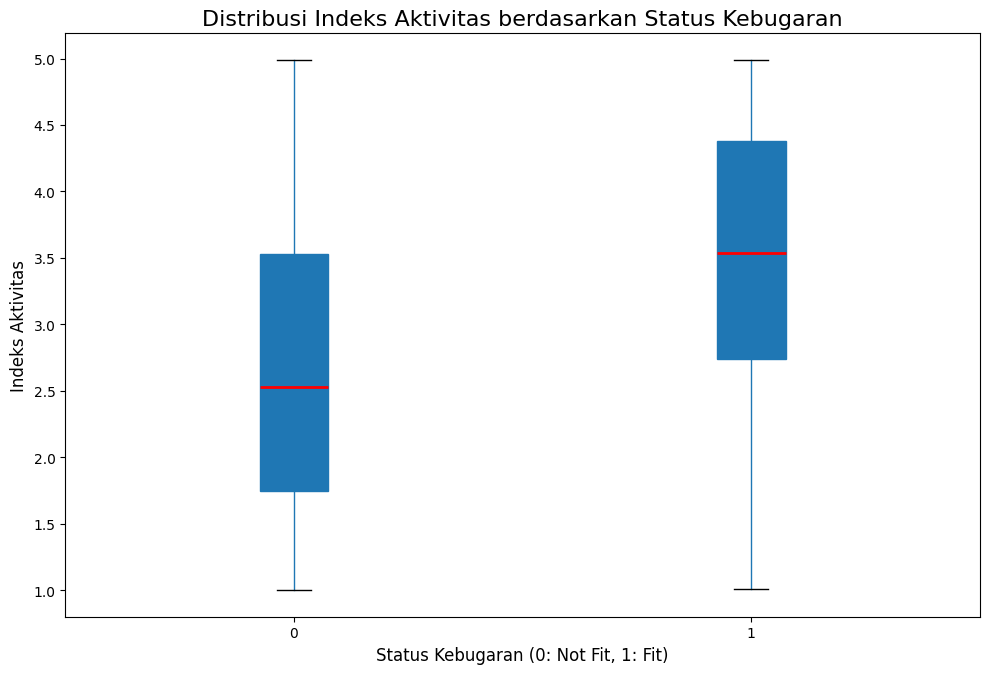

In [37]:
# Membersihkan figure agar tidak tumpang tindih jika dijalankan ulang
plt.figure(figsize=(10, 7))

# Membuat boxplot: column adalah variabel numerik (Activity Index)
# by adalah variabel kategori (is_fit: 0 = Not Fit, 1 = Fit)
df.boxplot(column='activity_index', by='is_fit', ax=plt.gca(),
           grid=False, patch_artist=True,
           medianprops=dict(color='red', linewidth=2))

plt.title('Distribusi Indeks Aktivitas berdasarkan Status Kebugaran', fontsize=16)
plt.xlabel('Status Kebugaran (0: Not Fit, 1: Fit)', fontsize=12)
plt.ylabel('Indeks Aktivitas', fontsize=12)
plt.suptitle('') # Menghilangkan judul default otomatis 'Boxplot grouped by is_fit'
plt.tight_layout()
plt.show()

Berdasarkan posisi kotak dan garis yang dihasilkan, kita bisa mendapatkan poin-poin berikut:

* **Nilai Median:** Anda bisa melihat apakah garis merah (median) pada kelompok "Fit" berada jauh lebih tinggi daripada kelompok "Not Fit". Hal ini membuktikan secara data bahwa individu yang bugar memiliki rata-rata indeks aktivitas yang lebih tinggi secara signifikan dibandingkan mereka yang tidak bugar.
* **Rentang Interkuartil (Box):** Anda dapat melihat variasi tingkat aktivitas melalui panjang kotak. Jika kotak pada kelompok "Fit" lebih pendek dan berada di posisi atas, hal ini menunjukkan bahwa orang bugar memiliki tingkat aktivitas yang konsisten tinggi, sedangkan kelompok "Not Fit" memiliki aktivitas yang lebih rendah dan cenderung lebih tersebar (variatif).
* **Deteksi Outlier:** Anda bisa mengidentifikasi titik-titik (pencilan) yang berada di luar garis "kumis" (whiskers). Titik-titik ini menunjukkan adanya pengguna "Not Fit" yang sebenarnya memiliki aktivitas cukup tinggi namun tetap tidak bugar, yang membantu mengidentifikasi adanya faktor penghambat lain seperti kualitas tidur atau nutrisi.
---
Hasil dari Boxplot ini memberikan arahan strategis bagi pengembangan fitur dan personalisasi pengguna:

* **Penentuan Ambang Batas Aktivitas:** Berdasarkan batas bawah kotak (Q1) pada kelompok "Fit", aplikasi dapat menentukan angka indeks aktivitas minimum yang wajib dicapai pengguna. Tindakannya adalah menetapkan target harian otomatis agar pengguna "Not Fit" terdorong untuk masuk ke rentang aktivitas kelompok bugar.
* **Evaluasi Faktor Pendukung:** Jika ditemukan banyak *outlier* pada kelompok "Not Fit" (orang yang aktivitasnya tinggi tapi tetap tidak bugar), tindakannya adalah memberikan kuesioner tambahan mengenai pola makan atau jam tidur, karena aktivitas fisik saja terbukti belum cukup bagi mereka.
* **Gamifikasi Berbasis Level:** Berdasarkan rentang kuartil yang ditemukan, perusahaan dapat membagi level pengguna dalam aplikasi. Tindakannya adalah memberikan lencana (badge) "Aktif" bagi mereka yang indeks aktivitasnya sudah menyentuh median kelompok "Fit" guna meningkatkan motivasi dan retensi pengguna.

## **Scatterplot**

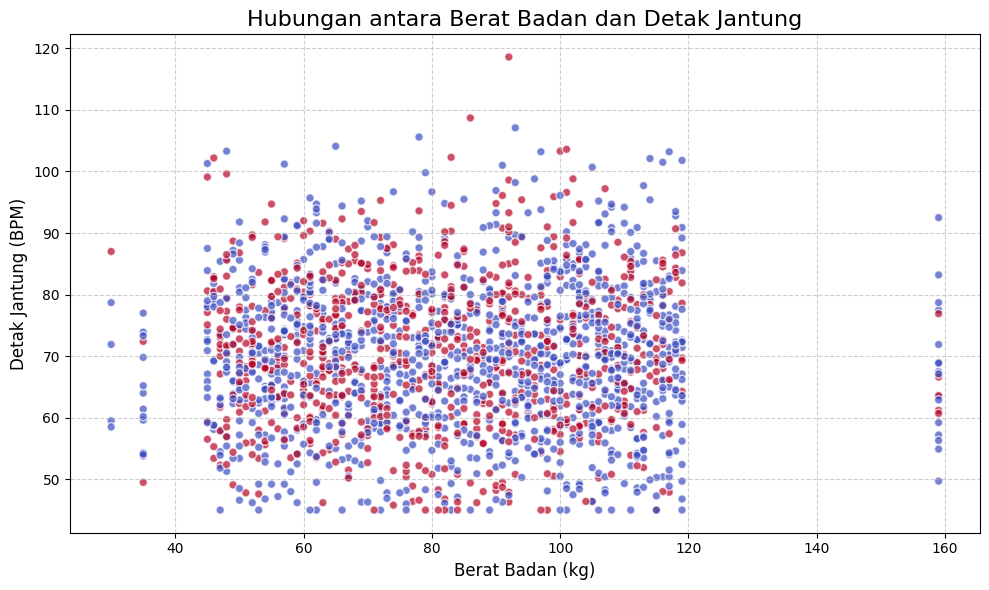

In [43]:
plt.figure(figsize=(10, 6))

# Membuat scatter plot
# cmap='coolwarm' memberikan gradasi warna yang jelas
scatter = plt.scatter(df['weight_kg'], df['heart_rate'],
                      c=df['is_fit'], cmap='coolwarm',
                      alpha=0.7, edgecolors='w')

plt.title('Hubungan antara Berat Badan dan Detak Jantung', fontsize=16)
plt.xlabel('Berat Badan (kg)', fontsize=12)
plt.ylabel('Detak Jantung (BPM)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Berdasarkan pola persebaran titik yang dihasilkan, kita bisa mendapatkan poin-poin berikut:

* **Pola Korelasi:** Anda bisa melihat apakah titik-titik cenderung naik ke arah kanan atas (korelasi positif). Jika berat badan yang lebih tinggi cenderung berpasangan dengan detak jantung yang lebih tinggi, ini menunjukkan adanya beban kerja jantung yang lebih berat pada individu dengan berat badan berlebih.
* **Sebaran Kategori (Clustering):** Anda dapat melihat di area mana warna tertentu (Fit vs Not Fit) mendominasi. Jika titik biru (Fit) mengelompok di area berat badan rendah dan detak jantung rendah, hal ini memberikan bukti visual bahwa kombinasi kedua faktor tersebut adalah kunci kebugaran.
* **Identifikasi Anomali:** Anda bisa menemukan titik-titik yang berada jauh dari kelompok utamanya. Misalnya, individu dengan berat badan tinggi namun memiliki detak jantung rendah dan berstatus "Fit"; hal ini bisa menunjukkan profil atlet atau individu dengan massa otot tinggi.
---
Hasil dari Scatter Plot ini memberikan arahan strategis bagi personalisasi dan pengembangan fitur:

* **Penentuan Zona Risiko:** Berdasarkan area di mana titik "Not Fit" paling banyak berkumpul, aplikasi dapat menetapkan "Zona Peringatan" otomatis bagi pengguna yang memiliki kombinasi berat badan dan detak jantung di angka tersebut.
* **Rekomendasi Latihan Spesifik:** Jika data menunjukkan detak jantung meningkat drastis seiring berat badan, tindakannya adalah merekomendasikan latihan kardio dengan intensitas rendah (*Low Impact*) agar tidak membebani kerja jantung pengguna secara berlebihan.
* **Optimalisasi Fitur Prediksi:** Scatter plot ini menunjukkan bahwa berat badan dan detak jantung saling berinteraksi secara kuat. Tindakannya adalah memastikan kedua variabel ini diprioritaskan sebagai fitur utama dalam pengembangan algoritma prediksi kesehatan di masa depan.


## **Heatmap**

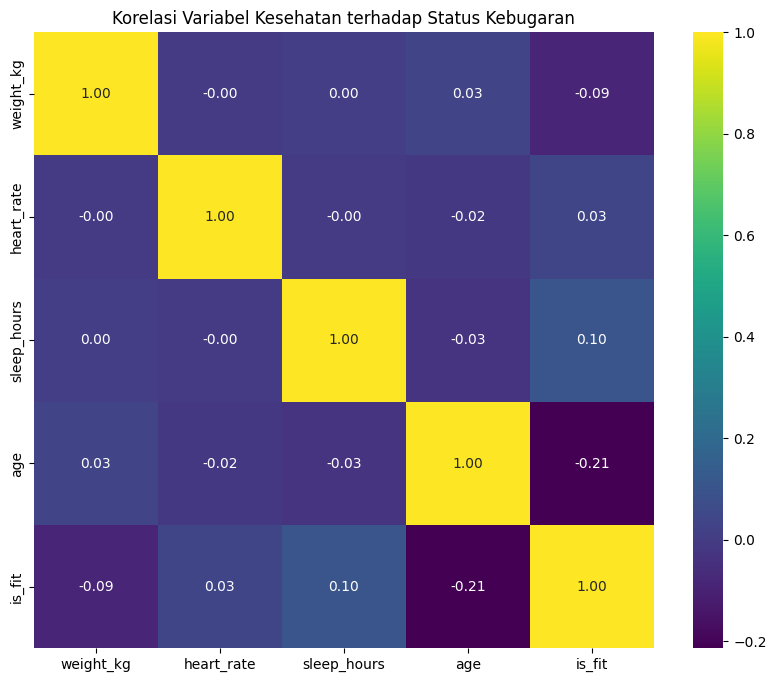

In [48]:
# Tambahkan is_fit dan age untuk melihat korelasi yang lebih luas
plt.figure(figsize=(10, 8))
sns.heatmap(data=df[['weight_kg', 'heart_rate', 'sleep_hours', 'age', 'is_fit']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')

plt.title('Korelasi Variabel Kesehatan terhadap Status Kebugaran')
plt.show()

Berdasarkan angka korelasi yang muncul setelah Anda menambahkan kolom lain, kita bisa mendapatkan poin-poin berikut:

* **Kekuatan Hubungan terhadap Target:** Anda bisa melihat angka korelasi pada baris atau kolom `is_fit`. Jika `heart_rate` memiliki angka negatif yang besar (misal -0.60) terhadap `is_fit`, itu memberikan wawasan bahwa detak jantung yang tinggi berhubungan erat dengan kondisi fisik yang tidak bugar.
* **Hubungan Antar Fitur (Feature Interaction):** Anda dapat melihat apakah `age` memiliki korelasi dengan `sleep_hours`. Jika angkanya mendekati 0, berarti usia seseorang dalam data ini tidak memengaruhi berapa lama mereka tidur.
* **Identifikasi Faktor Dominan:** Variabel dengan angka korelasi paling jauh dari 0 (baik positif maupun negatif) terhadap `is_fit` adalah faktor yang paling memengaruhi kebugaran dalam dataset Anda.
---
Hasil dari Heatmap yang lebih lengkap ini memberikan arahan strategis bagi analisis Anda:

* **Penyaringan Variabel (Feature Selection):** Berdasarkan nilai korelasi yang rendah (mendekati 0.00) terhadap `is_fit`, Anda bisa memutuskan untuk mengabaikan variabel tersebut dalam model prediksi karena dianggap tidak memberikan pengaruh nyata.
* **Fokus pada Faktor Kunci:** Jika `weight_kg` memiliki korelasi terkuat dibandingkan variabel lain, tindakannya adalah memprioritaskan akurasi penginputan data berat badan dan memberikan fitur pengingat timbangan rutin bagi pengguna.
* **Edukasi Berbasis Hubungan:** Jika data menunjukkan korelasi antara `sleep_hours` dan `heart_rate`, perusahaan dapat membuat fitur tips otomatis: "Tingkatkan jam tidur Anda untuk membantu menurunkan detak jantung istirahat."
